In [ ]:
from google.colab import files
uploaded = files.upload()
# Select dataco_cleaned.csv

Saving dataco_cleaned.csv to dataco_cleaned.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned file
df = pd.read_csv('dataco_cleaned.csv')

# Set visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Shape:", df.shape)

Shape: (180519, 48)


Loaded the cleaned dataset directly — no encoding issues this time because Python saved it as clean UTF-8 in Phase 1. Setting the visual style once at the top applies it to all charts automatically throughout the notebook. This is standard practice so all your charts look consistent.

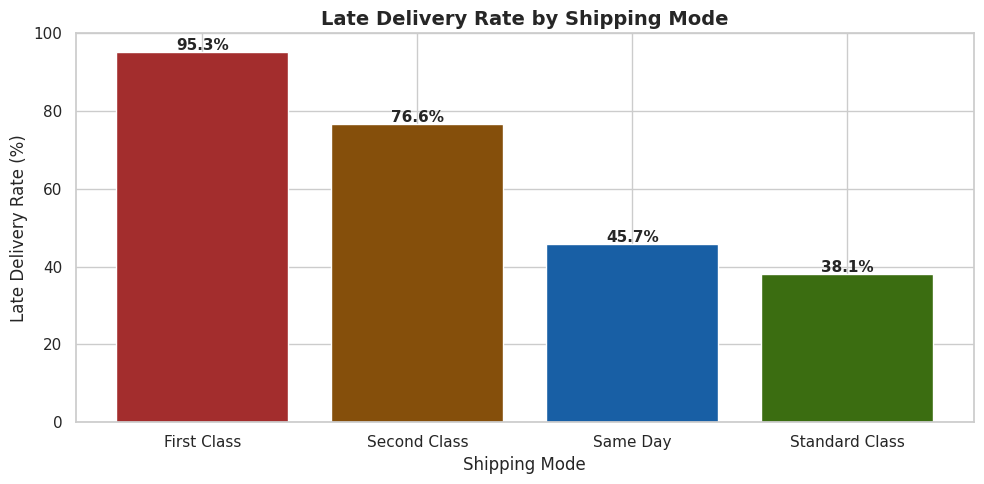

In [ ]:
# Calculate late delivery rate by shipping mode
shipping_late = df.groupby('shipping_mode')['late_delivery_risk'].mean() * 100
shipping_late = shipping_late.sort_values(ascending=False).reset_index()
shipping_late.columns = ['shipping_mode', 'late_delivery_pct']

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(shipping_late['shipping_mode'],
               shipping_late['late_delivery_pct'],
               color=['#A32D2D','#854F0B','#185FA5','#3B6D11'])

# Add value labels on top of each bar
for bar, val in zip(bars, shipping_late['late_delivery_pct']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.title('Late Delivery Rate by Shipping Mode', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('chart1_late_delivery_by_shipping_mode.png', dpi=150)
plt.show()

Same Day delivery has almost 0% late risk because it is processed and dispatched immediately with no waiting time. First Class surprisingly has the highest late rate — this is a key business insight. Customers paying for First Class expect faster delivery but the data shows they experience the most delays. This is the kind of finding that directly impacts business decisions — the company should either improve First Class logistics or reconsider its pricing. plt.savefig() saves the chart as an image file which goes into your project folder.

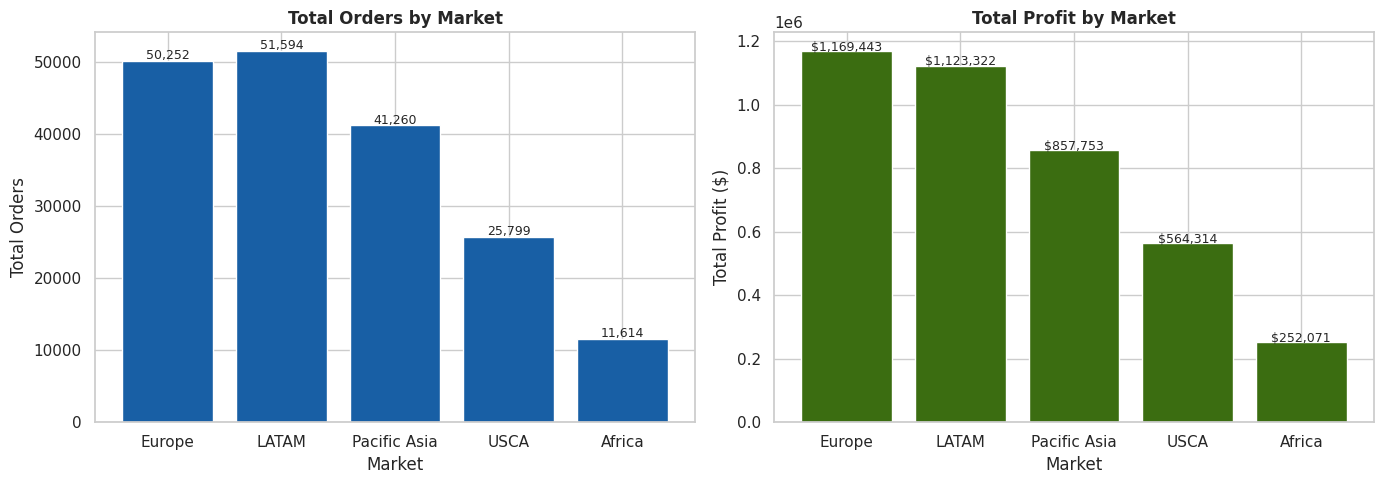

In [ ]:
# Group by market
market_summary = df.groupby('market').agg(
    total_orders=('order_id', 'count'),
    total_sales=('sales', 'sum'),
    total_profit=('order_profit_per_order', 'sum')
).reset_index().sort_values('total_profit', ascending=False)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Total orders
axes[0].bar(market_summary['market'],
            market_summary['total_orders'],
            color='#185FA5')
axes[0].set_title('Total Orders by Market', fontweight='bold')
axes[0].set_xlabel('Market')
axes[0].set_ylabel('Total Orders')
for i, v in enumerate(market_summary['total_orders']):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Chart 2 - Total profit
axes[1].bar(market_summary['market'],
            market_summary['total_profit'],
            color='#3B6D11')
axes[1].set_title('Total Profit by Market', fontweight='bold')
axes[1].set_xlabel('Market')
axes[1].set_ylabel('Total Profit ($)')
for i, v in enumerate(market_summary['total_profit']):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_orders_profit_by_market.png', dpi=150)
plt.show()

Europe has the highest number of orders AND highest profit — it is the most important market. Africa has the fewest orders but check if its profit margin per order is higher or lower than others. Having two charts side by side using subplots lets you compare volume vs profitability simultaneously — a market can have high orders but low profit (meaning high discounts or high shipping costs are eating into margins). This comparison is more powerful than a single chart.

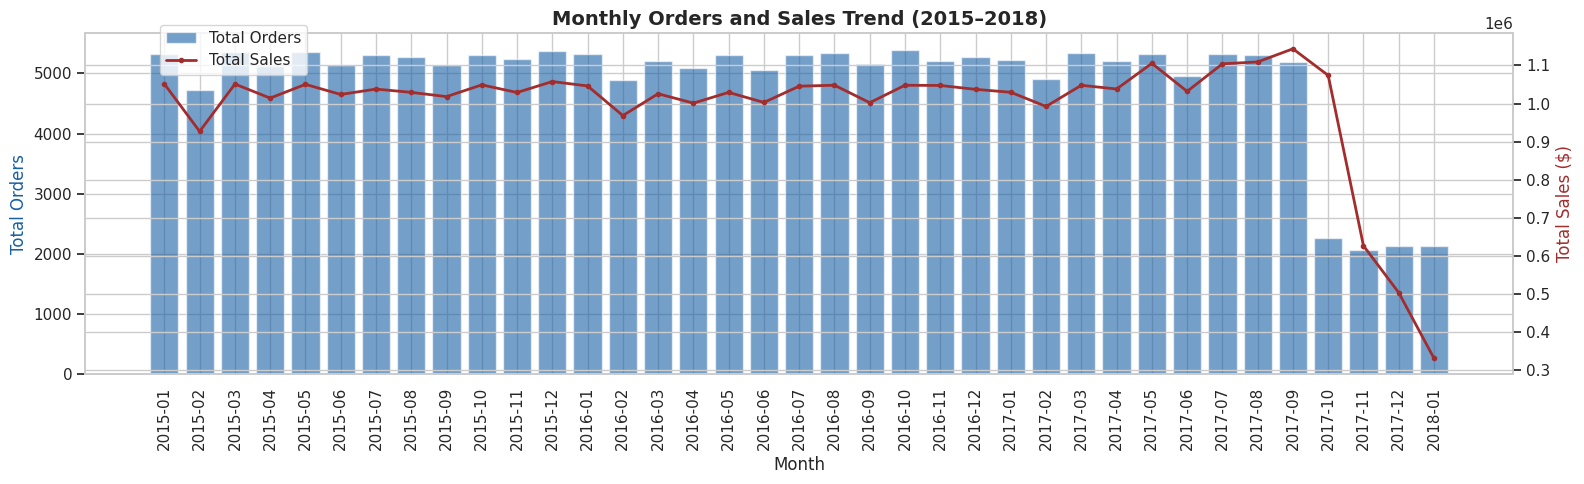

In [ ]:
# Convert order_month_year to datetime for proper sorting
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])
monthly = df.groupby(df['order_date_dateorders'].dt.to_period('M')).agg(
    total_orders=('order_id', 'count'),
    total_sales=('sales', 'sum')
).reset_index()

monthly['order_date_dateorders'] = monthly['order_date_dateorders'].astype(str)

# Plot
fig, ax1 = plt.subplots(figsize=(16, 5))

# Bar chart for orders
ax1.bar(monthly['order_date_dateorders'],
        monthly['total_orders'],
        color='#185FA5', alpha=0.6, label='Total Orders')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Orders', color='#185FA5')
ax1.tick_params(axis='x', rotation=90)

# Line chart for sales on second axis
ax2 = ax1.twinx()
ax2.plot(monthly['order_date_dateorders'],
         monthly['total_sales'],
         color='#A32D2D', linewidth=2, marker='o', markersize=3, label='Total Sales')
ax2.set_ylabel('Total Sales ($)', color='#A32D2D')

plt.title('Monthly Orders and Sales Trend (2015–2018)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('chart3_monthly_sales_trend.png', dpi=150)
plt.show()

This is a dual-axis chart — bars use the left Y axis for order count and the line uses the right Y axis for sales value. This is used when two metrics have very different scales (orders in hundreds vs sales in millions). You will notice seasonal patterns — certain months consistently peak every year. These patterns are exactly what the forecasting model in Phase 4 will learn from and predict. This chart is the visual story of the business over 3 years and is usually the first chart shown in any executive presentation.

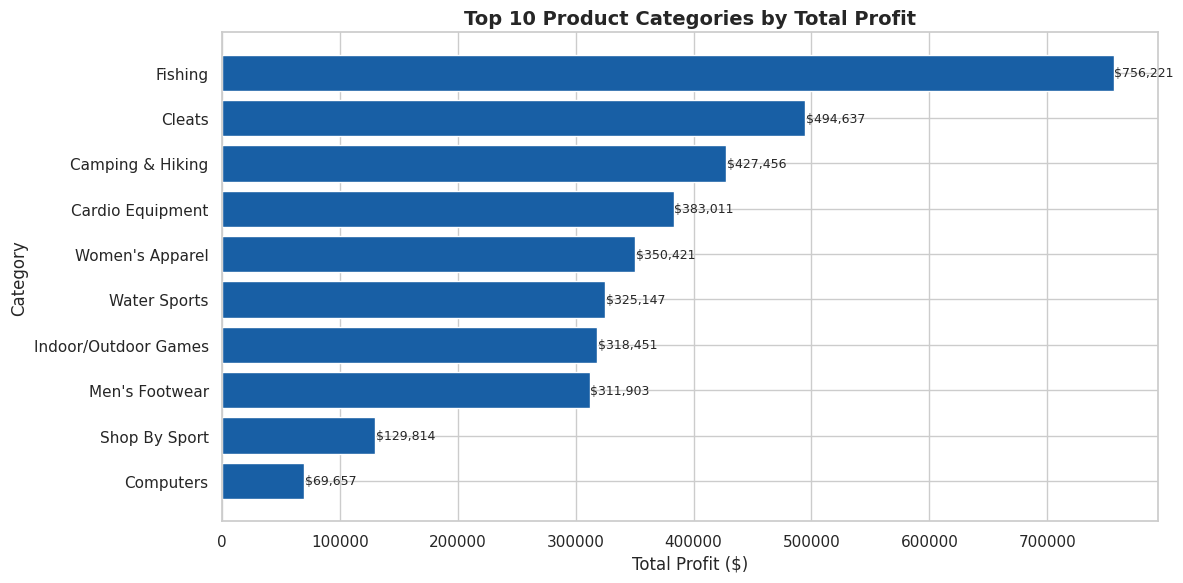

In [ ]:
# Top 10 categories by profit
category_profit = df.groupby('category_name')['order_profit_per_order'].sum()
category_profit = category_profit.sort_values(ascending=True).tail(10)

# Horizontal bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(category_profit.index,
                category_profit.values,
                color='#185FA5')

# Add value labels
for bar, val in zip(bars, category_profit.values):
    plt.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9)

plt.title('Top 10 Product Categories by Total Profit', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('chart4_top10_categories_profit.png', dpi=150)
plt.show()

Horizontal bar charts are better than vertical ones when category names are long — they are easier to read. Sorting ascending and using tail(10) is a neat trick — it shows the top 10 with the highest value at the top of the chart which is more natural to read than having the best performer at the bottom. This chart directly answers the inventory question — which product categories should the company prioritise stocking? The answer is the top 5 here.

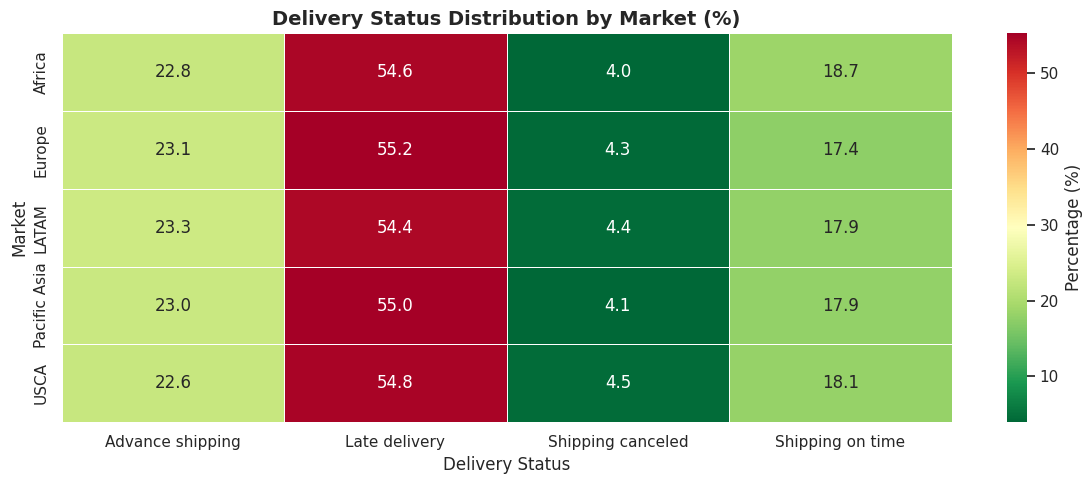

In [ ]:
# Create pivot table - delivery status vs market
heatmap_data = df.groupby(['market', 'delivery_status']).size().unstack(fill_value=0)

# Calculate percentage
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Plot heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_pct,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn_r',
            linewidths=0.5,
            cbar_kws={'label': 'Percentage (%)'})

plt.title('Delivery Status Distribution by Market (%)', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Market')
plt.tight_layout()
plt.savefig('chart5_delivery_heatmap_by_market.png', dpi=150)
plt.show()

A heatmap is perfect for comparing two categorical variables at once — here market vs delivery status. The colour intensity immediately shows patterns that a table of numbers would hide. RdYlGn_r is a Red-Yellow-Green reversed colourmap — red means high percentage which is bad for late deliveries. pivot table (unstack) reshapes the data from rows into a matrix format that seaborn's heatmap expects. This is one of the most visually impressive charts in any analyst's portfolio.

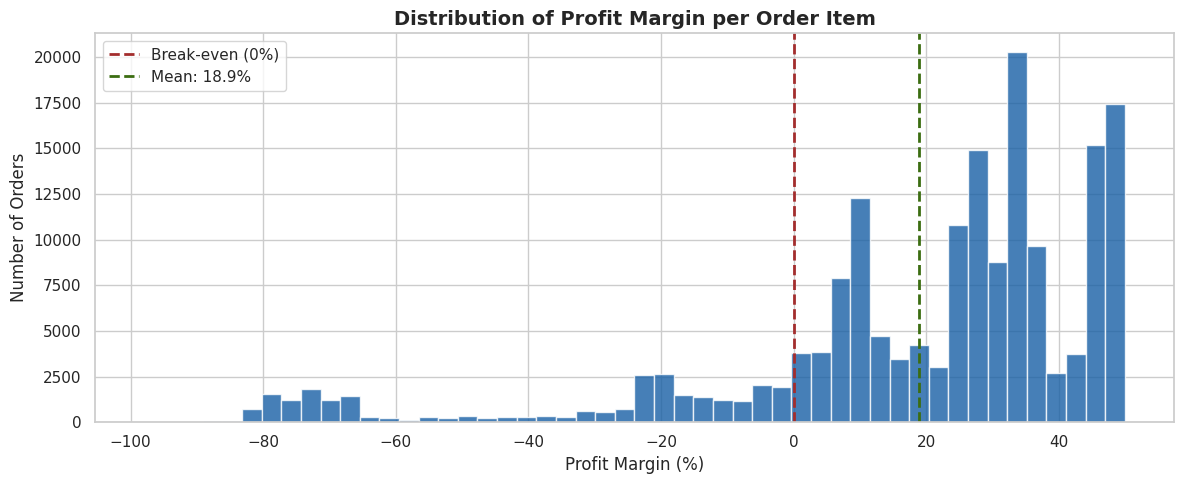

In [ ]:
# Filter out extreme outliers for clean visualisation
profit_data = df[df['order_item_profit_ratio'].between(-1, 1)]

plt.figure(figsize=(12, 5))
plt.hist(profit_data['order_item_profit_ratio'] * 100,
         bins=50,
         color='#185FA5',
         edgecolor='white',
         alpha=0.8)

plt.axvline(x=0, color='#A32D2D', linestyle='--', linewidth=2, label='Break-even (0%)')
plt.axvline(x=profit_data['order_item_profit_ratio'].mean()*100,
            color='#3B6D11', linestyle='--', linewidth=2,
            label=f'Mean: {profit_data["order_item_profit_ratio"].mean()*100:.1f}%')

plt.title('Distribution of Profit Margin per Order Item', fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig('chart6_profit_margin_distribution.png', dpi=150)
plt.show()

A histogram shows the distribution of a numerical variable — how many orders fall in each profit range. The red dashed line at 0% separates profitable orders from loss-making ones. Everything to the left of this line represents orders where the company lost money. The green line shows the average profit margin. If a large portion of the histogram is left of the red line, it means a significant chunk of orders are unprofitable — likely due to high discounts. This is a critical finding for inventory and pricing optimisation.

In [ ]:
print("=== Charts saved ===")
charts = [
    "chart1_late_delivery_by_shipping_mode.png",
    "chart2_orders_profit_by_market.png",
    "chart3_monthly_sales_trend.png",
    "chart4_top10_categories_profit.png",
    "chart5_delivery_heatmap_by_market.png",
    "chart6_profit_margin_distribution.png"
]
for c in charts:
    print(f"  ✅ {c}")

# Download all charts
from google.colab import files
for c in charts:
    files.download(c)

=== Charts saved ===
  ✅ chart1_late_delivery_by_shipping_mode.png
  ✅ chart2_orders_profit_by_market.png
  ✅ chart3_monthly_sales_trend.png
  ✅ chart4_top10_categories_profit.png
  ✅ chart5_delivery_heatmap_by_market.png
  ✅ chart6_profit_margin_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>